# MAI 600 — Module 1 Assignment 1: Token & Cost Audit

**Student:** Cristina Naramoto   **Course:** MAI 600 — Natural Language Processing   **Institution:** Atlantis University

**Domain selected: Risk Management**

---

## 1. Scenario and Corpus Selection

For this assignment I selected an **enterprise risk management workflow**. The imagined organization is a mid-sized financial services company whose risk team receives incident reports, risk register entries, regulatory text, and committee communications that analysts summarize and classify using an LLM.

The corpus contains **seven non-sensitive text samples written specifically for this assignment**. No real company names, account numbers, monetary exposures, vendor names, or internal identifiers are included — all names, codes, and figures are realistic placeholders.

**Real workflow selected:** summarize and classify monthly operational risk incident reports for the risk team's triage and quarterly trend analysis.

The document set was chosen to cover the main text types the risk function actually handles, including one structured risk-register entry, one Python snippet used for quantitative risk (Value-at-Risk), and one document in Portuguese, since risk reporting in my context is often bilingual (English/Portuguese).

In [1]:
%%capture
# Setup — installs the tokenizer (needed on Google Colab)
%pip install -q tiktoken

## 2. Sample Document Set

| ID | Type | Field / Topic |
|----|------|---------------|
| Doc 1 | Risk assessment excerpt | Enterprise Risk Management |
| Doc 2 | Incident / loss event report | Operational Risk |
| Doc 3 | Regulatory / compliance text | Financial Risk / Compliance (Basel-style) |
| Doc 4 | Risk register entry (structured) | Risk Governance |
| Doc 5 | Business email | Risk Communication |
| Doc 6 | Code snippet (Python) | Quantitative Risk — Monte Carlo VaR |
| Doc 7 | Multilingual text (Portuguese) | Risk Management / Multilingual |

The full text of each document is defined in the code cell below.

In [2]:
# Risk Management corpus for MAI600 Token & Cost Audit — all synthetic, non-sensitive
CORPUS = {
    "Doc 1": {
        "type": "Risk assessment excerpt",
        "field": "Enterprise Risk Management",
        "text": (
            "The annual enterprise risk assessment identified supply chain disruption as the "
            "highest residual risk for the coming fiscal year. Although the organization has "
            "diversified its supplier base across three regions, several critical components "
            "still depend on a single vendor. The risk committee evaluated the likelihood as "
            "moderate and the potential impact as severe, given that a prolonged disruption "
            "could delay product delivery by up to ninety days. Existing mitigation measures "
            "include safety stock policies, dual-sourcing agreements for high-volume parts, "
            "and quarterly vendor financial health reviews. The committee recommended "
            "increasing the safety stock threshold for critical components and initiating "
            "qualification of an alternate supplier before the end of the second quarter. "
            "Residual risk will be reassessed after these actions are completed and reported "
            "to the board through the standard risk dashboard."
        ),
    },
    "Doc 2": {
        "type": "Incident / loss event report",
        "field": "Operational Risk",
        "text": (
            "On the morning of the reporting date, the payments reconciliation process failed "
            "to complete before the daily cutoff. The root cause was a scheduling conflict "
            "introduced during a routine system update, which caused the batch job to start "
            "two hours late. Approximately 1,400 transactions were settled after the deadline, "
            "resulting in estimated interest compensation of $8,500 payable to affected "
            "counterparties. No customer data was exposed and no regulatory reporting "
            "threshold was breached. The operations team implemented a temporary manual "
            "checkpoint and the technology team added an automated alert that triggers if the "
            "batch job has not started within fifteen minutes of its scheduled time. The event "
            "was classified as an operational loss under process execution failure and "
            "recorded in the loss event database for quarterly trend analysis."
        ),
    },
    "Doc 3": {
        "type": "Regulatory / compliance text",
        "field": "Financial Risk / Compliance",
        "text": (
            "Institutions must maintain a minimum Common Equity Tier 1 (CET1) capital ratio "
            "of 4.5 percent of risk-weighted assets, plus a capital conservation buffer of "
            "2.5 percent, resulting in an effective minimum of 7 percent under normal "
            "conditions. Risk-weighted assets shall be calculated using either the "
            "standardized approach or, subject to supervisory approval, the internal "
            "ratings-based (IRB) approach. Institutions applying the IRB approach must "
            "demonstrate that their probability of default (PD), loss given default (LGD), "
            "and exposure at default (EAD) models are validated annually by an independent "
            "function. Failure to maintain the required ratios restricts discretionary "
            "distributions, including dividends and bonus payments, until the buffer is "
            "restored. Supervisors may impose additional Pillar 2 requirements based on the "
            "institution's risk profile and stress testing results."
        ),
    },
    "Doc 4": {
        "type": "Risk register entry (structured)",
        "field": "Risk Governance",
        "text": (
            "RISK-2026-0147 | Category: Third-Party / Vendor | Status: OPEN\n"
            "Inherent score: L4 x I5 = 20 (Critical) | Residual score: L2 x I4 = 8 (High)\n"
            "Owner: VP_Procurement | Review date: 2026-09-30 | KRI: vendor_sla_breaches >= 3/qtr\n"
            "Description: Concentration risk — 62% of cloud spend with single provider.\n"
            "Mitigations: [M-01] multi-cloud pilot (in progress), [M-02] exit clause "
            "renegotiation (done), [M-03] DR failover test scheduled 2026-08-15.\n"
            "Linked incidents: INC-0892, INC-0911 | Appetite: OUTSIDE tolerance — escalate to ERC."
        ),
    },
    "Doc 5": {
        "type": "Business email",
        "field": "Risk Communication",
        "text": (
            "Subject: Pre-read for Thursday's Enterprise Risk Committee\n\n"
            "Dear committee members,\n\n"
            "Ahead of Thursday's meeting, please review the attached quarterly risk report. "
            "Three items require a decision. First, the cyber insurance renewal quote came in "
            "22 percent above last year, and we need to decide whether to accept the higher "
            "premium or increase our retention. Second, the fraud losses in the digital "
            "channel exceeded the monthly tolerance for the second consecutive month, so the "
            "first line has proposed additional verification steps that may add friction for "
            "customers. Third, the internal audit findings on model documentation remain open "
            "past their due date and require a revised remediation plan. Please come prepared "
            "to vote on each item. The meeting will be held in the main boardroom and remote "
            "dial-in details are included in the calendar invitation.\n\n"
            "Best regards,\nHead of Enterprise Risk"
        ),
    },
    "Doc 6": {
        "type": "Code snippet",
        "field": "Quantitative Risk / Python",
        "text": (
            "import numpy as np\n\n"
            "def monte_carlo_var(returns, n_sims=10_000, horizon=10, alpha=0.99):\n"
            "    \"\"\"Estimate Value-at-Risk via Monte Carlo simulation.\"\"\"\n"
            "    mu, sigma = returns.mean(), returns.std()\n"
            "    sim = np.random.normal(mu, sigma, (n_sims, horizon)).sum(axis=1)\n"
            "    var_99 = -np.percentile(sim, (1 - alpha) * 100)\n"
            "    es_99 = -sim[sim <= -var_99].mean()  # expected shortfall\n"
            "    return {\"VaR_99\": var_99, \"ES_99\": es_99}\n"
        ),
    },
    "Doc 7": {
        "type": "Multilingual text (Portuguese)",
        "field": "Risk Management / Multilingual",
        "text": (
            "A área de gestão de riscos concluiu a revisão trimestral do apetite de risco da "
            "organização. O comitê aprovou a redução do limite de exposição cambial de dez "
            "para oito por cento do patrimônio líquido, considerando a maior volatilidade "
            "esperada nos mercados emergentes. Além disso, o indicador-chave de risco "
            "relacionado à inadimplência da carteira de crédito permaneceu dentro da "
            "tolerância estabelecida, embora tenha apresentado tendência de alta pelo terceiro "
            "mês consecutivo. A equipe recomendou o monitoramento semanal desse indicador até "
            "o final do próximo trimestre e a atualização do plano de contingência de liquidez. "
            "Os resultados dos testes de estresse serão apresentados ao conselho de "
            "administração na próxima reunião ordinária, com destaque para os cenários de "
            "aumento acelerado das taxas de juros."
        ),
    },
}

for doc_id, d in CORPUS.items():
    print(f"{doc_id} — {d['type']} ({d['field']}) — {len(d['text'].split())} words")


Doc 1 — Risk assessment excerpt (Enterprise Risk Management) — 130 words
Doc 2 — Incident / loss event report (Operational Risk) — 127 words
Doc 3 — Regulatory / compliance text (Financial Risk / Compliance) — 123 words
Doc 4 — Risk register entry (structured) (Risk Governance) — 77 words
Doc 5 — Business email (Risk Communication) — 139 words
Doc 6 — Code snippet (Quantitative Risk / Python) — 47 words
Doc 7 — Multilingual text (Portuguese) (Risk Management / Multilingual) — 122 words


## 3. Tokenization and Token Count Table

I tokenize each document with **`tiktoken`** using the `cl100k_base` encoding (the tokenizer used by GPT-3.5/GPT-4). Word count uses simple whitespace splitting, matching the approach used in class.

In [3]:
import tiktoken
import pandas as pd

enc = tiktoken.get_encoding("cl100k_base")   # GPT-3.5 / GPT-4 tokenizer

rows = []
for doc_id, d in CORPUS.items():
    words = len(d["text"].split())
    tokens = len(enc.encode(d["text"]))
    rows.append({
        "Document ID": doc_id,
        "Document Type": d["type"],
        "Field / Topic": d["field"],
        "Word Count": words,
        "Token Count": tokens,
        "Token-to-Word Ratio": round(tokens / words, 2),
    })

df = pd.DataFrame(rows)

notes = {
    "Doc 1": "Plain business English; lowest ratio in the set.",
    "Doc 2": "Mostly plain English; numbers ($8,500, 1,400) split into extra tokens.",
    "Doc 3": "Acronyms (CET1, IRB, PD, LGD, EAD) and percentages inflated the ratio.",
    "Doc 4": "IDs, pipes, scores and dates fragment heavily; highest count per word of any prose doc.",
    "Doc 5": "Conversational email text; close to plain-English baseline.",
    "Doc 6": "Code: underscores, operators and syntax push the ratio to ~3 tokens per word.",
    "Doc 7": "Portuguese accented words split into sub-word pieces under cl100k_base.",
}
df["Notes"] = df["Document ID"].map(notes)

avg = {
    "Document ID": "Average", "Document Type": "", "Field / Topic": "",
    "Word Count": round(df["Word Count"].mean(), 1),
    "Token Count": round(df["Token Count"].mean(), 1),
    "Token-to-Word Ratio": round(df["Token Count"].sum() / df["Word Count"].sum(), 2),
    "Notes": "Corpus-level ratio (total tokens / total words).",
}
df_display = pd.concat([df, pd.DataFrame([avg])], ignore_index=True)
df_display

,Document ID,Document Type,Field / Topic,Word Count,Token Count,Token-to-Word Ratio,Notes
0,Doc 1,Risk assessment excerpt,Enterprise Risk Management,130.0,145.0,1.12,Plain business English; lowest ratio in the set.
1,Doc 2,Incident / loss event report,Operational Risk,127.0,143.0,1.13,"Mostly plain English; numbers ($8,500, 1,400) ..."
2,Doc 3,Regulatory / compliance text,Financial Risk / Compliance,123.0,170.0,1.38,"Acronyms (CET1, IRB, PD, LGD, EAD) and percent..."
3,Doc 4,Risk register entry (structured),Risk Governance,77.0,171.0,2.22,"IDs, pipes, scores and dates fragment heavily;..."
4,Doc 5,Business email,Risk Communication,139.0,163.0,1.17,Conversational email text; close to plain-Engl...
5,Doc 6,Code snippet,Quantitative Risk / Python,47.0,141.0,3.00,"Code: underscores, operators and syntax push t..."
6,Doc 7,Multilingual text (Portuguese),Risk Management / Multilingual,122.0,214.0,1.75,Portuguese accented words split into sub-word ...
7,Average,,,109.3,163.9,1.50,Corpus-level ratio (total tokens / total words).


### Resulting token count table

| Document ID | Document Type | Field / Topic | Word Count | Token Count | Token-to-Word Ratio | Notes |
|---|---|---|---|---|---|---|
| Doc 1 | Risk assessment excerpt | Enterprise Risk Mgmt | 130 | 145 | 1.12 | Plain business English; lowest ratio in the set. |
| Doc 2 | Incident / loss event report | Operational Risk | 127 | 143 | 1.13 | Mostly plain English; numbers split into extra tokens. |
| Doc 3 | Regulatory / compliance text | Financial Risk / Compliance | 123 | 170 | 1.38 | Acronyms (CET1, IRB, PD, LGD, EAD) and percentages inflated the ratio. |
| Doc 4 | Risk register entry (structured) | Risk Governance | 77 | 171 | 2.22 | IDs, pipes, scores and dates fragment heavily. |
| Doc 5 | Business email | Risk Communication | 139 | 163 | 1.17 | Conversational email text; near plain-English baseline. |
| Doc 6 | Code snippet | Quantitative Risk / Python | 47 | 141 | 3.00 | Underscores, operators and syntax ≈ 3 tokens per word. |
| Doc 7 | Multilingual (Portuguese) | Risk Mgmt / Multilingual | 122 | 214 | 1.75 | Accented Portuguese words split into sub-word pieces. |
| **Average** | | | **109.3** | **163.9** | **1.50** | Corpus-level ratio (total tokens / total words). |

## 4. Observations About Tokenization

To understand *why* the ratios differ so much, I inspected how the tokenizer actually splits representative pieces of text:

In [4]:
samples = [
    "reconciliation",        # long English word
    "CET1",                  # regulatory acronym
    "RISK-2026-0147",        # risk register ID
    "monte_carlo_var",       # code identifier
    "$8,500",                # currency amount
    "gestão",                # Portuguese accented word
    "inadimplência",         # Portuguese domain term
]
for s in samples:
    pieces = [enc.decode([t]) for t in enc.encode(s)]
    print(f"{s!r:20} -> {len(pieces)} tokens: {pieces}")

'reconciliation'     -> 2 tokens: ['re', 'conciliation']
'CET1'               -> 3 tokens: ['C', 'ET', '1']
'RISK-2026-0147'     -> 8 tokens: ['R', 'ISK', '-', '202', '6', '-', '014', '7']
'monte_carlo_var'    -> 5 tokens: ['mont', 'e', '_car', 'lo', '_var']
'$8,500'             -> 4 tokens: ['$', '8', ',', '500']
'gestão'             -> 2 tokens: ['gest', 'ão']
'inadimplência'      -> 4 tokens: ['in', 'ad', 'impl', 'ência']


**What I noticed:**

- **Plain business English is the cheapest text.** Docs 1, 2 and 5 stayed near 1.1–1.2 tokens per word because common English words usually map to a single token.
- **Long words are not the problem — unusual words are.** `reconciliation` (14 letters) costs only 2 tokens because it is common in training data.
- **Acronyms fragment.** `CET1` becomes `C` + `ET` + `1` (3 tokens for one "word"). Risk vocabulary is full of acronyms (IRB, PD, LGD, EAD, KRI, ERC), which quietly raises cost in regulatory text (Doc 3, ratio 1.38).
- **Numbers and currency split.** `$8,500` becomes 4 tokens (`$`, `8`, `,`, `500`); percentages and dates behave similarly. Risk documents are dense with numbers.
- **Structured text is expensive.** The risk register entry (Doc 4) hit a 2.22 ratio: IDs like `RISK-2026-0147` alone cost 8 tokens, and pipes, colons and score notation (`L4 x I5 = 20`) each become separate tokens.
- **Code is the most expensive per word.** Doc 6 reached 3.0: `monte_carlo_var` splits into 5 tokens, and every parenthesis, operator, and line break is tokenized.
- **Punctuation-heavy formatting adds up.** Quotes, brackets and underscores in notes and tickets all consume tokens without adding words.
- **Multilingual text pays a penalty.** Portuguese (Doc 7) hit 1.75 under `cl100k_base`: accented words like `gestão` (2 tokens) and `inadimplência` (4 tokens) split into sub-word pieces because the tokenizer's vocabulary is English-centric. (Section 7 shows a newer tokenizer cuts this penalty dramatically.)
- **Domain vocabulary matters.** Terms like `counterparties` and `inadimplência` are rare enough to fragment, so risk-domain text is systematically more expensive than everyday English of the same length.

## 5. Context Window Reflection

**Which document consumes the most context-window space?** Doc 7 (Portuguese) had the highest absolute token count (214) despite a mid-range word count, and Doc 6 (code) had the highest ratio (3.0). Per unit of *information*, the structured register entry (Doc 4) is also very expensive — 171 tokens for 77 words.

**What if a workflow included hundreds of documents?** At the corpus average of ~164 tokens per short document, 1,000 documents would need ~164,000 tokens *before* adding the system prompt, instructions, and output space. That already approaches or exceeds many context windows (e.g., 128K), so the model would either truncate documents, lose earlier context, or fail. Long incident reports, raw structured exports, and bilingual duplicates would consume the window fastest.

**What I would remove, summarize, or chunk:**
- **Remove** boilerplate that repeats in every report (headers, disclaimers, signature blocks) and redundant bilingual copies when one language suffices for the task.
- **Summarize** older incident history into short rolling summaries instead of resending full reports each month.
- **Chunk** long incident reports by section (root cause, impact, remediation) and send only the sections the task needs.
- **Pre-process structured data**: convert register entries like Doc 4 into compact normalized fields (or let a database do the filtering) instead of pasting raw pipe-delimited text into the prompt.

## 6. Monthly Token Cost Estimate

**Workflow:** summarize and classify **500 operational risk incident reports per month** for triage and quarterly trend analysis.

Real incident reports are longer than my classroom samples, so I estimated **800 input tokens** per report (report text + instructions) and **150 output tokens** per report (a short summary plus category and severity labels).

Formula used:

```
Monthly input tokens  = average input tokens per task  × number of tasks per month
Monthly output tokens = average output tokens per task × number of tasks per month
Total monthly tokens  = monthly input tokens + monthly output tokens
```

In [5]:
avg_input_tokens  = 800    # report text + instructions (real reports are longer than class samples)
avg_output_tokens = 150    # short summary + category + severity
reports_per_month = 500

monthly_input  = avg_input_tokens  * reports_per_month
monthly_output = avg_output_tokens * reports_per_month
total_monthly  = monthly_input + monthly_output

# Classroom example pricing (same illustrative model as the instructor example):
price_in_per_M, price_out_per_M = 0.50, 1.50   # USD per 1M tokens

cost_in  = monthly_input  / 1_000_000 * price_in_per_M
cost_out = monthly_output / 1_000_000 * price_out_per_M

print(f"Monthly input tokens : {monthly_input:>9,}   ({avg_input_tokens} x {reports_per_month})")
print(f"Monthly output tokens: {monthly_output:>9,}   ({avg_output_tokens} x {reports_per_month})")
print(f"Total monthly tokens : {total_monthly:>9,}")
print()
print(f"Input cost : {monthly_input/1e6:.3f}M x ${price_in_per_M:.2f}  = ${cost_in:.2f}")
print(f"Output cost: {monthly_output/1e6:.3f}M x ${price_out_per_M:.2f}  = ${cost_out:.2f}")
print(f"Estimated monthly total: ${cost_in + cost_out:.2f}")

Monthly input tokens :   400,000   (800 x 500)
Monthly output tokens:    75,000   (150 x 500)
Total monthly tokens :   475,000

Input cost : 0.400M x $0.50  = $0.20
Output cost: 0.075M x $1.50  = $0.11
Estimated monthly total: $0.31


| Metric | Value | Calculation / Explanation |
|---|---|---|
| Average input tokens per report | 800 | Real reports are longer than the classroom samples; includes instructions. |
| Average output tokens per summary | 150 | Short summary + category + severity. |
| Reports per month | 500 | Estimated monthly incident volume for a mid-sized risk team. |
| Monthly input tokens | 400,000 | 800 × 500 |
| Monthly output tokens | 75,000 | 150 × 500 |
| **Total monthly tokens** | **475,000** | Input + output |

| Cost Component | Calculation | Estimated Cost |
|---|---|---|
| Input cost | 0.400M × $0.50 | $0.20 |
| Output cost | 0.075M × $1.50 | $0.11 |
| **Estimated monthly total** | $0.20 + $0.11 | **$0.31** |

> *Note: these are classroom example prices only (same illustrative pricing used in the instructor example). With current public pricing from a commercial provider the total would still be well under a few dollars per month at this volume — the interesting cost driver at scale is not this workflow but adding long documents, history, or retrieval context to every request.*

In [6]:
# Bonus: the same workflow priced with current public provider pricing
# (Anthropic list prices per 1M tokens, checked July 2026)
pricing_models = {
    "Classroom example ($0.50/$1.50)": (0.50, 1.50),
    "Claude Haiku 4.5 ($1/$5)":        (1.00, 5.00),
    "Claude Sonnet 5 ($3/$15)":        (3.00, 15.00),
    "Claude Opus 4.8 ($5/$25)":        (5.00, 25.00),
}

comparison = pd.DataFrame([
    {
        "Pricing model": name,
        "Input cost": round(monthly_input / 1_000_000 * p_in, 2),
        "Output cost": round(monthly_output / 1_000_000 * p_out, 2),
        "Monthly total (USD)": round(
            monthly_input / 1_000_000 * p_in + monthly_output / 1_000_000 * p_out, 2
        ),
    }
    for name, (p_in, p_out) in pricing_models.items()
])
comparison

,Pricing model,Input cost,Output cost,Monthly total (USD)
0,Classroom example ($0.50/$1.50),0.2,0.11,0.31
1,Claude Haiku 4.5 ($1/$5),0.4,0.38,0.78
2,Claude Sonnet 5 ($3/$15),1.2,1.12,2.33
3,Claude Opus 4.8 ($5/$25),2.0,1.88,3.88


### Bonus: comparison with current public provider pricing

To sanity-check the classroom estimate, I also priced the same workflow (400K input + 75K output tokens per month) with **current public Anthropic pricing** (July 2026, USD per 1M tokens):

| Pricing model | Input $/1M | Output $/1M | Monthly total |
|---|---|---|---|
| Classroom example (instructor's model) | $0.50 | $1.50 | **$0.31** |
| Claude Haiku 4.5 | $1.00 | $5.00 | **$0.78** |
| Claude Sonnet 5 | $3.00 | $15.00 | **$2.33** |
| Claude Opus 4.8 | $5.00 | $25.00 | **$3.88** |

**Takeaway:** even with the most capable (and most expensive) model, this workflow costs under $4 per month. At this volume, the per-token price is *not* the real cost driver — what changes the economics at scale is **how many tokens each request carries** (long documents, conversation history, retrieval context). A workflow that attached each incident's full history could easily multiply the input tokens by 10–50×, which would matter far more than the choice between a $1 and a $5 model.

## 7. Extra Challenge — High-Code Track

### 7.1 Comparing two tokenizers

I compared **`cl100k_base`** (GPT-3.5/GPT-4, ~100K vocabulary) against **`o200k_base`** (GPT-4o, ~200K vocabulary) across the whole corpus programmatically.

In [7]:
enc_a = tiktoken.get_encoding("cl100k_base")   # GPT-3.5 / GPT-4
enc_b = tiktoken.get_encoding("o200k_base")    # GPT-4o (larger, more multilingual vocab)

comp_rows = []
for doc_id, d in CORPUS.items():
    words = len(d["text"].split())
    ta, tb = len(enc_a.encode(d["text"])), len(enc_b.encode(d["text"]))
    comp_rows.append({
        "Document ID": doc_id,
        "Type": d["type"],
        "Words": words,
        "cl100k_base": ta,
        "o200k_base": tb,
        "Ratio cl100k": round(ta / words, 2),
        "Ratio o200k": round(tb / words, 2),
        "Savings %": round((ta - tb) / ta * 100, 1),
    })
comp = pd.DataFrame(comp_rows)
comp

,Document ID,Type,Words,cl100k_base,o200k_base,Ratio cl100k,Ratio o200k,Savings %
0,Doc 1,Risk assessment excerpt,130,145,145,1.12,1.12,0.0
1,Doc 2,Incident / loss event report,127,143,143,1.13,1.13,0.0
2,Doc 3,Regulatory / compliance text,123,170,169,1.38,1.37,0.6
3,Doc 4,Risk register entry (structured),77,171,171,2.22,2.22,0.0
4,Doc 5,Business email,139,163,162,1.17,1.17,0.6
5,Doc 6,Code snippet,47,141,140,3.00,2.98,0.7
6,Doc 7,Multilingual text (Portuguese),122,214,156,1.75,1.28,27.1


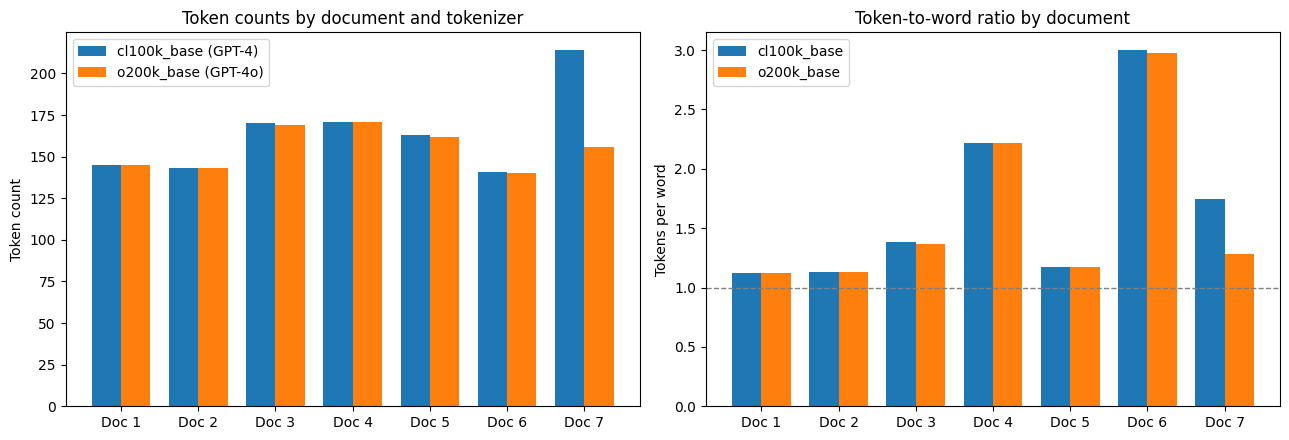

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(comp))
w = 0.38
ax1.bar(x - w/2, comp["cl100k_base"], w, label="cl100k_base (GPT-4)")
ax1.bar(x + w/2, comp["o200k_base"], w, label="o200k_base (GPT-4o)")
ax1.set_xticks(x, comp["Document ID"])
ax1.set_ylabel("Token count")
ax1.set_title("Token counts by document and tokenizer")
ax1.legend()

ax2.bar(x - w/2, comp["Ratio cl100k"], w, label="cl100k_base")
ax2.bar(x + w/2, comp["Ratio o200k"], w, label="o200k_base")
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax2.set_xticks(x, comp["Document ID"])
ax2.set_ylabel("Tokens per word")
ax2.set_title("Token-to-word ratio by document")
ax2.legend()

plt.tight_layout()
plt.show()

**Key finding:** the two tokenizers are nearly identical on English prose, structured text, and code — but differ sharply on the **Portuguese document (Doc 7): 214 tokens under `cl100k_base` vs 156 under `o200k_base`, a ~27% reduction.** The larger, more multilingual vocabulary of `o200k_base` stores whole Portuguese word pieces that `cl100k_base` has to fragment. For a bilingual risk workflow, tokenizer/model choice directly changes the cost and context usage of every non-English document.

### 7.2 Local compute footprint estimate

If the same monthly workflow (475,000 tokens: 400K in / 75K out) ran on a **local open-weights model (~7–8B parameters, 4-bit quantized)** on a single consumer GPU:

| Item | Estimate | Reasoning |
|---|---|---|
| Model memory (weights) | ~4–5 GB VRAM | 7–8B params × ~0.5–0.6 bytes at 4-bit |
| KV cache per request | tens of MB | ~1K-token context per report is small |
| Prompt processing (prefill) | ~5–10 min/month | 400K input tokens at ~1,000+ tokens/s |
| Generation | ~30–40 min/month | 75K output tokens at ~30–50 tokens/s |
| **Total GPU time** | **< 1 hour/month** | Well within a single workstation |

**Memory, latency, and cost implications:** token count drives all three. Every input token must be processed in prefill and held in the KV cache (memory grows linearly with context length); every output token costs one generation step (latency grows linearly with output length); and hosted APIs bill per token, so the token-to-word ratio of a domain is effectively a price multiplier — my risk corpus at ratio 1.50 costs ~25% more per word than plain English at ~1.2.

**Local vs hosted trade-off:** at 475K tokens/month, a hosted API costs well under a dollar with the classroom pricing — far cheaper than buying and running a GPU. Local inference wins only when volume is much higher, when data cannot leave the organization (a real constraint for risk and compliance data), or when latency/customization requirements dominate. For confidential incident reports, a risk team might accept the higher infrastructure cost of local or private hosting specifically for data governance reasons — a risk-management decision in itself.

## 8. Short Written Summary

What caught my attention the most was that the number of words does not necessarily mean a text will use fewer tokens. Even a short text can consume many tokens when it contains code, acronyms, or technical terms. In my corpus, the Python code snippet had the highest token-to-word ratio (3.0 — 141 tokens from only 47 words), and the Portuguese document produced the highest absolute token count (214 tokens). I also learned that some texts in Portuguese use more tokens because words with accents can be split into several parts. Newer tokenizers, however, can reduce the number of tokens needed — the same Portuguese text used about 27% fewer tokens with `o200k_base` than with `cl100k_base`.

I also understood that tokens are important not only because of the cost, but also because they limit how much information the model can process at one time. For this reason, in real projects it is better to avoid sending repeated information, summarize older texts, split large documents into smaller sections, and store structured data in a database instead of putting everything into the prompt. This makes the processing more efficient and can also reduce costs.

## 9. AI Tool Usage Disclosure

| Disclosure Item | Response |
|---|---|
| **AI tools used** | Claude Code (Anthropic) |
| **How I used them** | I used Claude Code to help set up the tokenization notebook, generate realistic non-sensitive sample risk-management texts, explain tokenizer behavior (BPE sub-word splitting), and format the tables and charts. |
| **What I verified myself** | I ran every cell in the notebook and confirmed the token counts, ratios, and monthly cost calculations; I reviewed each sample document to confirm it contains no real or sensitive data; and I checked the tokenizer comparison results against the raw `tiktoken` output. |
| **What I changed or corrected after using AI** | I adjusted the workflow volume and token-per-report assumptions to match a realistic mid-sized risk team, revised the reflection to describe my own conclusions, and confirmed the classroom example pricing was clearly labeled as illustrative. |

## 10. Student Checklist

- [x] Corpus contains 5–8 non-sensitive text samples (7 samples, all synthetic)
- [x] Token table includes word count, token count, and token-to-word ratio
- [x] Monthly token estimate uses a clear formula
- [x] Reflection connects token count to cost, context windows, memory, and workflow design
- [x] AI usage disclosure is included
- [x] Extra Challenge (High-Code): two tokenizers compared, charts, compute footprint, local vs hosted trade-offs